# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
# Import your chosen baseline model
# Example: from sklearn.linear_model import LogisticRegression
import h5py
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


## Model Choice

Random Forest was chosen as the baseline model because it provides a robust and interpretable nonlinear classifier that performs well on limited and potentially noisy experimental datasets. Unlike linear models, it can capture complex relationships within ARPES spectra without extensive preprocessing or feature engineering

## Feature Selection

We are using the measured intensity per pixel as the feature.


In [ ]:
# Load the dataset

hf = h5py.File('.../ML/data/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5', 'r')
labels_df = pd.read_excel('.../ML/data/Classification_table_Version3.xlsx', usecols=['Resolution'])

# Feature selection
general_group = hf.get('entry')
acquisition_group = general_group.get('acquisition')
data = acquisition_group.get('data')

# Samples nach vorne bringen
X = np.transpose(data, (2, 0, 1))
print(X.shape)

# Flatten
X = X.reshape(1765, -1)
print(X.shape)

y = labels_df['Resolution']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(1765, 288, 216)
(1765, 62208)


## Implementation

In [ ]:
# Initialize and train the baseline model
model = Pipeline([
    ("pca", PCA(n_components=50)),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pca', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[0,1,2,3,4]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,62208
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many sa

## Evaluation

We use primarily the precision of label 4, because it is important for us, that the suggested spectra really are of the highest quality. The accuracy is an additional assurance of the general performance to be sure the labeling of the other classes works as intended.



In [4]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [5]:
# Evaluate the baseline model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Macro F1-Score: {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.870
Macro F1-Score: 0.855

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94        97
           1       0.93      0.87      0.90        31
           2       0.81      0.64      0.72        45
           3       0.80      0.94      0.87       123
           4       0.92      0.79      0.85        57

    accuracy                           0.87       353
   macro avg       0.88      0.84      0.85       353
weighted avg       0.87      0.87      0.87       353


Confusion Matrix:
[[ 90   2   3   2   0]
 [  3  27   1   0   0]
 [  1   0  29  15   0]
 [  0   0   3 116   4]
 [  0   0   0  12  45]]


### Cross-Validation

In [6]:
# cross-validation score 
from sklearn.model_selection import cross_val_score 
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean()}")
print(f"Standard Deviation of CV scores: {cv_scores.std():.3f}")


Cross-validation scores: [0.55240793 0.8611898  0.898017   0.81586402 0.74787535]
Mean CV score: 0.775070821529745
Standard Deviation of CV scores: 0.122


### Comparison of the set labels and the predicted labels as heatmaps

Predicted class distribution:
0 435
1 166
2 207
3 656
4 301
2
Total samples: 1765, Padded samples: 1767
0 4


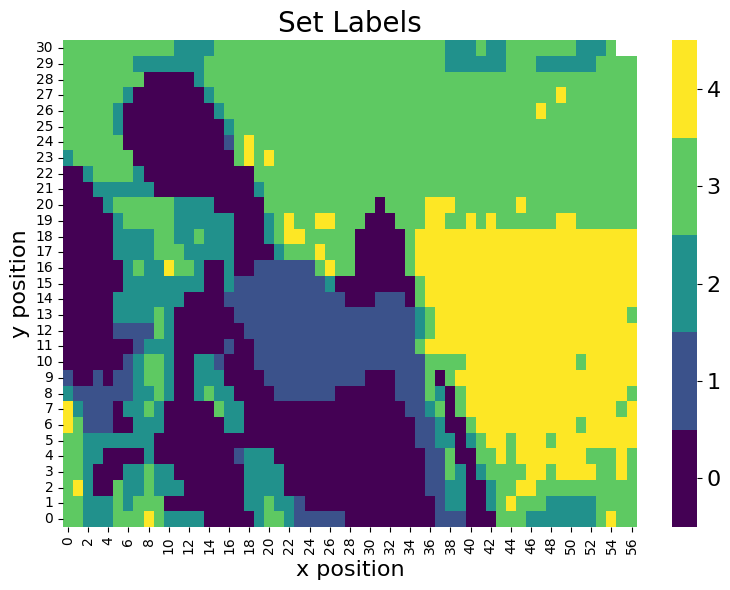

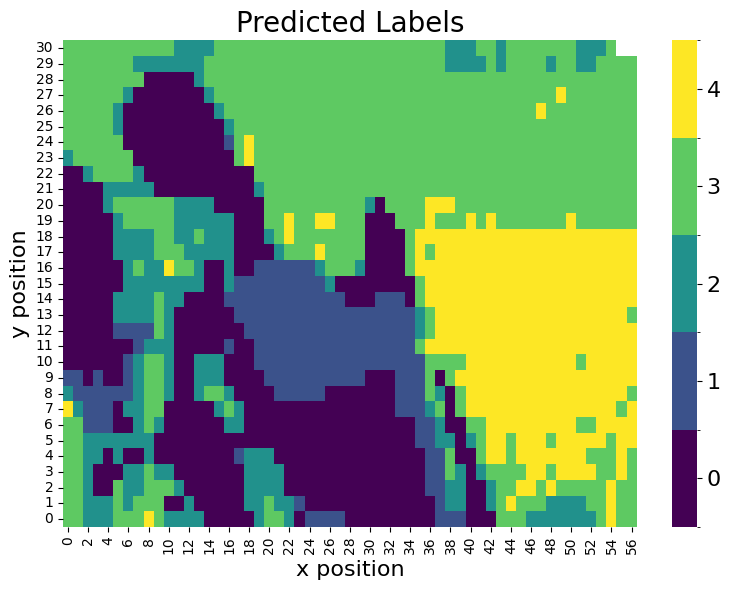

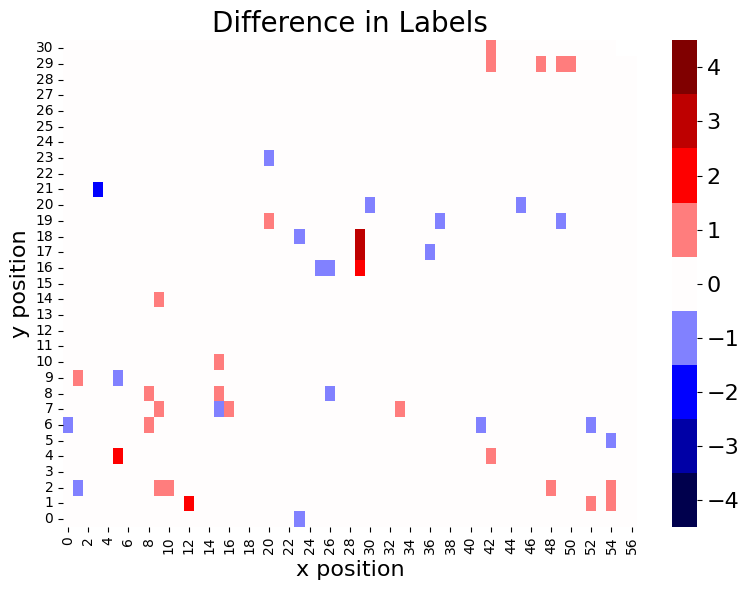

In [37]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import TwoSlopeNorm

x = 57  # number of measurements (ARPES spectra) in x direction on sample

# --------------------------------------------------
# Predictions
# --------------------------------------------------
y_pred_full = model.predict(X)

# Debug: Show predicted class distribution
unique, counts = np.unique(y_pred_full, return_counts=True)
print("Predicted class distribution:")
for u, c in zip(unique, counts):
    print(u, c)

# --------------------------------------------------
# Convert predictions to matrix
# --------------------------------------------------
arr = np.asarray(y_pred_full, dtype=float)

pad_len = (-len(arr)) % x
print(pad_len)
print(f"Total samples: {len(arr)}, Padded samples: {len(arr)+pad_len}")

arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)

# --------------------------------------------------
# Convert ground truth to matrix
# --------------------------------------------------
true_array = np.asarray(y, dtype=float)

pad_len_true = (-len(true_array)) % x
true_array_padded = np.pad(
    true_array,
    (0, pad_len_true),
    constant_values=np.nan
)

true_matrix = true_array_padded.reshape(-1, x)

# --------------------------------------------------
# Difference matrix
# --------------------------------------------------
diff_matrix = pred_matrix - true_matrix


# --------------------------------------------------
# Discrete colormap for classes 0-4
# --------------------------------------------------
colors = [
    "#440154",  # 0
    "#3b528b",  # 1
    "#21918c",  # 2
    "#5ec962",  # 3
    "#fde725"   # 4
]

class_cmap = ListedColormap(colors)
class_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), class_cmap.N)

# Discrete normalization for differences (-4 ... 4)
diff_norm = BoundaryNorm(np.arange(-4.5, 5.5, 1), 256)

# ==================================================
# Ground Truth
# ==================================================
label_min = np.min(y)
label_max = np.max(y)
print(label_min, label_max)
bounds = np.arange(label_min - 0.5, label_max + 1.5, 1)
#cmap = plt.get_cmap("tab20", n_colors)
plt.figure(figsize=(8,6))
ax = sns.heatmap(true_matrix, cmap=class_cmap, cbar=True, linewidths=0.0,
                 cbar_kws={"ticks": np.arange(label_min, label_max + 1),"boundaries": bounds})
ax.invert_yaxis()
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.title(f'Set Labels', size=20)
plt.xlabel('x position', size=16)
plt.ylabel('y position', size=16)
plt.tight_layout()

plt.savefig(
            f"true_label_matrix.pdf",
            bbox_inches="tight",
            pad_inches=0.06
         )

plt.show()

plt.figure(figsize=(8,6))
ax = sns.heatmap(pred_matrix, cmap=class_cmap, norm=class_norm, cbar=True, linewidths=0.0,
                 cbar_kws={"ticks": np.arange(label_min, label_max + 1),"boundaries": bounds})
ax.invert_yaxis()
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.title(f'Predicted Labels', size=20)
plt.xlabel('x position', size=16)
plt.ylabel('y position', size=16)
plt.tight_layout()

plt.savefig(
            f"RF_pred_label_matrix.pdf",
            bbox_inches="tight",
            pad_inches=0.06
         )


plt.show()


norm = TwoSlopeNorm(vmin=-label_max, vcenter=0, vmax=label_max)
bounds = np.arange(-label_max - 0.5, label_max + 1.5, 1)
plt.figure(figsize=(8,6))
ax = sns.heatmap(diff_matrix, cmap='seismic', norm=norm, cbar=True, linewidths=0.0,
                 cbar_kws={"ticks": np.arange(-label_max, label_max + 1),"boundaries": bounds})
ax.invert_yaxis()
cbar = ax.collections[0].colorbar
cbar.set_ticks(np.arange(-4, 5))
cbar.ax.tick_params(labelsize=16)
plt.title(f'Difference in Labels', size=20)
plt.xlabel('x position', size=16)
plt.ylabel('y position', size=16)
plt.tight_layout()

plt.savefig(
            f"RF_diff_label_matrix.pdf",
            bbox_inches="tight",
            pad_inches=0.06
         )


plt.show()



### Model application to one other dataset

(288, 216, 67)
(1296, 288, 216)
Predicted class distribution:
0 441
2 829
3 20
4 6
0
Total samples: 1296, Padded samples: 1296


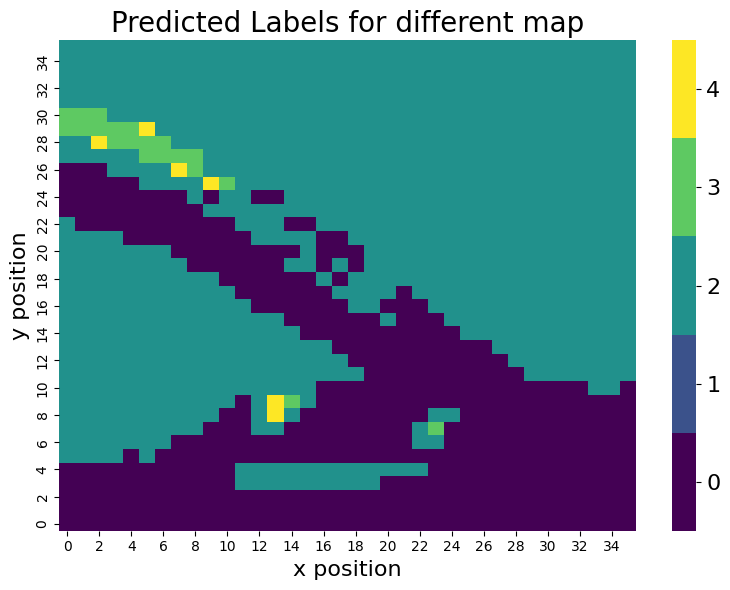

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py

h5_path_3 = '.../ML/data/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135747.h5'

with h5py.File(h5_path_3, "r", libver="latest", swmr=True) as f:
    data = f["entry/acquisition/data"]
    num_samples = data.shape[2]
    print(data.chunks)

    x = 36

    X_test2 = np.transpose(data[...], (2, 0, 1))
    print(X_test2.shape)

    X_test2 = X_test2.reshape(num_samples, -1)

    y_pred_full2 = model.predict(X_test2)

# --------------------------------------------------
# Debug: Show predicted class distribution
# --------------------------------------------------
unique, counts = np.unique(y_pred_full2, return_counts=True)

print("Predicted class distribution:")
for u, c in zip(unique, counts):
    print(u, c)

# --------------------------------------------------
# Convert predictions to matrix
# --------------------------------------------------
arr = np.asarray(y_pred_full2, dtype=float)

pad_len = (-len(arr)) % x

print(pad_len)
print(f"Total samples: {len(arr)}, Padded samples: {len(arr)+pad_len}")

arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)


# --------------------------------------------------
# Discrete colormap
# --------------------------------------------------
colors = [
    "#440154",  # Klasse 0
    "#3b528b",  # Klasse 1
    "#21918c",  # Klasse 2
    "#5ec962",  # Klasse 3
    "#fde725"   # Klasse 4
]

class_cmap = ListedColormap(colors)
class_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), class_cmap.N)

# --------------------------------------------------
# Plot
# --------------------------------------------------
label_min = np.min(y)
label_max = np.max(y)

bounds = np.arange(label_min - 0.5, label_max + 1.5, 1)

fig, ax = plt.subplots(figsize=(8, 6))

ax = sns.heatmap(pred_matrix, cmap=class_cmap, cbar=True, linewidths=0.0,
                 cbar_kws={"ticks": np.arange(label_min, label_max + 1),"boundaries": bounds})
ax.invert_yaxis()
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.title(f'Predicted Labels for different map', size=20)
plt.xlabel('x position', size=16)
plt.ylabel('y position', size=16)
plt.tight_layout()

plt.savefig(
            f"RF_pred_label_matrix_map2.pdf",
            bbox_inches="tight",
            pad_inches=0.06
         )


plt.show()